<a href="https://colab.research.google.com/github/jaumg2004/xGMobile/blob/main/TrabalhoFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sistema de Análise de Crédito  
Nomes: Kauã de Oliveira Ribeiro, João Gabriel F. Ribeiro

In [15]:
!pip install category_encoders

In [16]:
# Importando as bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from category_encoders import TargetEncoder
from scipy.stats import mstats
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    precision_recall_curve,
)


In [17]:
# Importa os arquivos csv com os dados dos clientes
app_df = pd.read_csv("application_record.csv")
credit_df = pd.read_csv("credit_record.csv")

print("Tabela de Aplicações:")
display(app_df)

print("\nTabela de Histórico de Crédito:")
display(credit_df)

Tabela de Aplicações:


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438552,6840104,M,N,Y,0,135000.0,Pensioner,Secondary / secondary special,Separated,House / apartment,-22717,365243,1,0,0,0,NaN,1.0
438553,6840222,F,N,N,0,103500.0,Working,Secondary / secondary special,Single / not married,House / apartment,-15939,-3007,1,0,0,0,Laborers,1.0
438554,6841878,F,N,N,0,54000.0,Commercial associate,Higher education,Single / not married,With parents,-8169,-372,1,1,0,0,Sales staff,1.0
438555,6842765,F,N,Y,0,72000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-21673,365243,1,0,0,0,NaN,2.0



Tabela de Histórico de Crédito:


,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C
...,...,...,...
1048570,5150487,-25,C
1048571,5150487,-26,C
1048572,5150487,-27,C
1048573,5150487,-28,C


In [18]:
# ==========================================
# CÉLULA 1: LIMPEZA E ENGENHARIA DE DADOS
# ==========================================

# 1. Renomeando colunas do application_record para português intuitivo
app_df.rename(columns={
    'CODE_GENDER': 'Genero',
    'FLAG_OWN_CAR': 'Tem_Carro',
    'FLAG_OWN_REALTY': 'Tem_Imovel',
    'CNT_CHILDREN': 'Qtd_Filhos',
    'AMT_INCOME_TOTAL': 'Renda_Anual',
    'NAME_INCOME_TYPE': 'Tipo_Renda',
    'NAME_EDUCATION_TYPE': 'Escolaridade',
    'NAME_FAMILY_STATUS': 'Estado_Civil',
    'NAME_HOUSING_TYPE': 'Tipo_Moradia',
    'DAYS_BIRTH': 'Idade',
    'DAYS_EMPLOYED': 'Anos_Empregado',
    'FLAG_MOBIL': 'Tem_Celular',
    'FLAG_WORK_PHONE': 'Tem_Tel_Trabalho',
    'FLAG_PHONE': 'Tem_Tel_Fixo',
    'FLAG_EMAIL': 'Tem_Email',
    'OCCUPATION_TYPE': 'Profissao',
    'CNT_FAM_MEMBERS': 'Tamanho_Familia'
}, inplace=True)

# 2. Convertendo dias negativos para anos
app_df['Idade'] = np.abs(round(app_df['Idade'] / 365.25))
app_df['Anos_Empregado'] = np.where(
    app_df['Anos_Empregado'] > 0, 0,
    np.abs(round(app_df['Anos_Empregado'] / 365.25))
)

# 3. Trocando 'Y' e 'N' por 1 e 0
app_df['Tem_Carro']  = app_df['Tem_Carro'].map({'Y': 1, 'N': 0})
app_df['Tem_Imovel'] = app_df['Tem_Imovel'].map({'Y': 1, 'N': 0})

# 4. Renomeando colunas do credit_record
credit_df.rename(columns={
    'MONTHS_BALANCE': 'Meses_no_Banco',
    'STATUS': 'Status_Pagamento'
}, inplace=True)

status_map = {
    'C': 'Pago (Em dia)',
    'X': 'Sem empréstimo no mês',
    '0': 'Atraso leve (1-29 dias)',
    '1': 'Atraso médio (30-59 dias)',
    '2': 'Atraso grave (60-89 dias)',
    '3': 'Atraso grave (90-119 dias)',
    '4': 'Atraso grave (120-149 dias)',
    '5': 'Dívida podre (>150 dias)'
}
credit_df['Status_Descricao'] = credit_df['Status_Pagamento'].map(status_map)

MESES_AVALIACAO = 6  # janela de avaliação de risco (ajuste conforme o negócio)

# Meses_no_Banco é negativo: 0 = mês atual, -1 = mês anterior, etc.
historico_passado   = credit_df[credit_df['Meses_no_Banco'] < -MESES_AVALIACAO]
periodo_avaliacao   = credit_df[credit_df['Meses_no_Banco'] >= -MESES_AVALIACAO]

# 5. Variável alvo: mau pagador se teve atraso grave no PERÍODO DE AVALIAÇÃO
periodo_avaliacao = periodo_avaliacao.copy()
periodo_avaliacao['Mau_Pagador'] = periodo_avaliacao['Status_Pagamento'].isin(
    ['2', '3', '4', '5']
)
target_df = periodo_avaliacao.groupby('ID')['Mau_Pagador'].max().reset_index()

# 6. Features de histórico criadas apenas com o HISTÓRICO PASSADO
historico_features = historico_passado.groupby('ID').agg(
    Qtd_Meses_Historico        = ('Status_Pagamento', 'count'),
    Qtd_Atrasos_Leves          = ('Status_Pagamento', lambda x: x.isin(['0', '1']).sum()),
    Qtd_Atrasos_Graves         = ('Status_Pagamento', lambda x: x.isin(['2', '3', '4', '5']).sum()),
    Qtd_Meses_Pagos            = ('Status_Pagamento', lambda x: (x == 'C').sum()),
    Qtd_Meses_Sem_Emprestimo   = ('Status_Pagamento', lambda x: (x == 'X').sum()),
).reset_index()

historico_features['Percentual_Atrasos_Graves'] = (
    historico_features['Qtd_Atrasos_Graves'] / historico_features['Qtd_Meses_Historico']
)

# 7. Unindo as tabelas
df = app_df.merge(target_df, on='ID', how='inner')
df = df.merge(historico_features, on='ID', how='left')

# 8. Preenchendo valores faltantes
df['Profissao'] = df['Profissao'].fillna('Nao Informado')
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# 9. Convertendo alvo para inteiro
df['Mau_Pagador'] = df['Mau_Pagador'].astype(int)

# 10. Winsorização da renda (trata outliers extremos antes do split)
# Limita o 1% superior da renda para evitar que valores absurdos
# distorçam o modelo, mesmo usando RobustScaler depois.
df['Renda_Anual'] = mstats.winsorize(df['Renda_Anual'], limits=[0, 0.01])

print("Dados limpos e organizados com sucesso!")
print(f"   Shape final: {df.shape}")
print(f"   Taxa de maus pagadores: {df['Mau_Pagador'].mean():.2%}")
display(df.head())

Dados limpos e organizados com sucesso!
   Shape final: (27363, 25)
   Taxa de maus pagadores: 0.67%


,ID,Genero,Tem_Carro,Tem_Imovel,Qtd_Filhos,Renda_Anual,Tipo_Renda,Escolaridade,Estado_Civil,Tipo_Moradia,...,Tem_Email,Profissao,Tamanho_Familia,Mau_Pagador,Qtd_Meses_Historico,Qtd_Atrasos_Leves,Qtd_Atrasos_Graves,Qtd_Meses_Pagos,Qtd_Meses_Sem_Emprestimo,Percentual_Atrasos_Graves
0,5008804,M,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,0,Nao Informado,2.0,0,9.0,2.0,0.0,6.0,1.0,0.0
1,5008805,M,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,0,Nao Informado,2.0,0,8.0,2.0,0.0,5.0,1.0,0.0
2,5008806,M,1,1,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,...,0,Security staff,2.0,0,23.0,7.0,0.0,0.0,16.0,0.0
3,5008808,F,0,1,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,1,Sales staff,1.0,0,17.0,6.0,0.0,0.0,0.0,0.0
4,5008810,F,0,1,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,1,Sales staff,1.0,0,20.0,6.0,0.0,8.0,6.0,0.0


/tmp/ipykernel_29719/135233907.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Mau_Pagador', palette=['#2ecc71', '#e74c3c'], ax=axes[0,0])
/tmp/ipykernel_29719/135233907.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,0].set_xticklabels(['Bom Pagador', 'Mau Pagador'])
/tmp/ipykernel_29719/135233907.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y='Escolaridade', x='Renda_Anual', palette='viridis', ax=axes[1,0])
/tmp/ipykernel_29719/135233907.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the

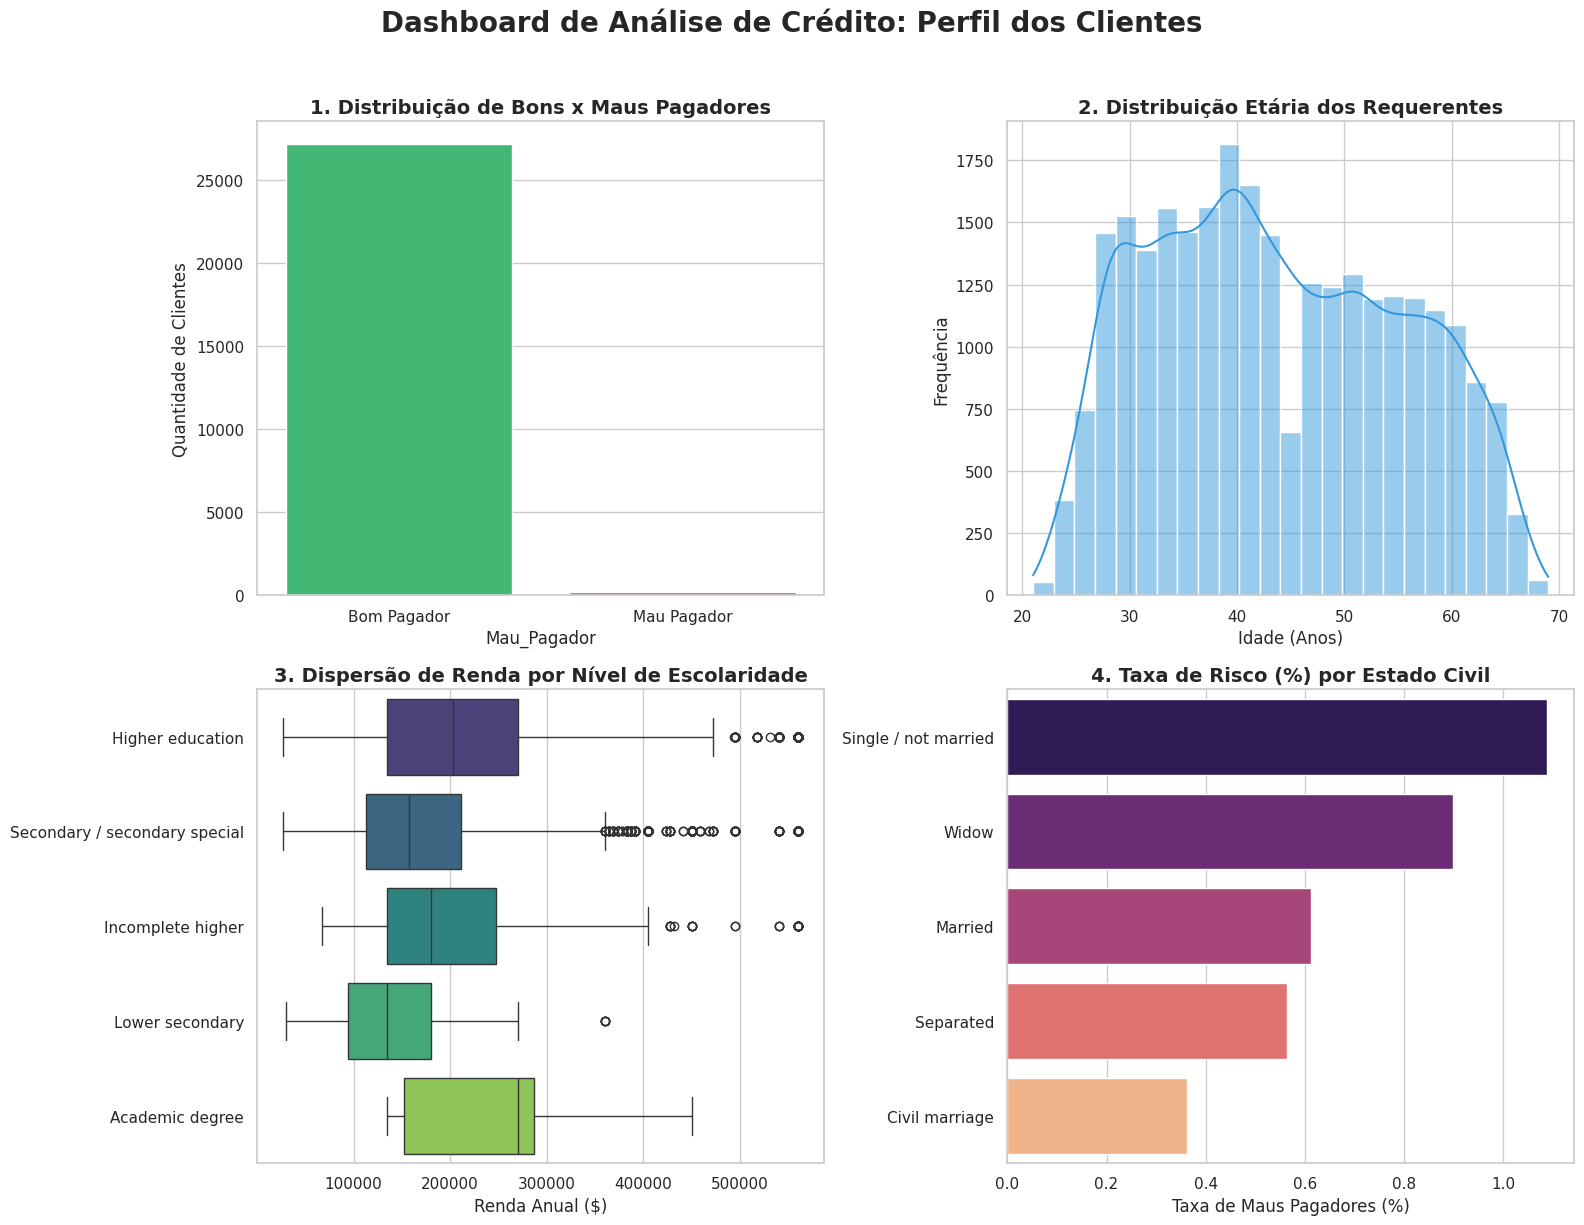

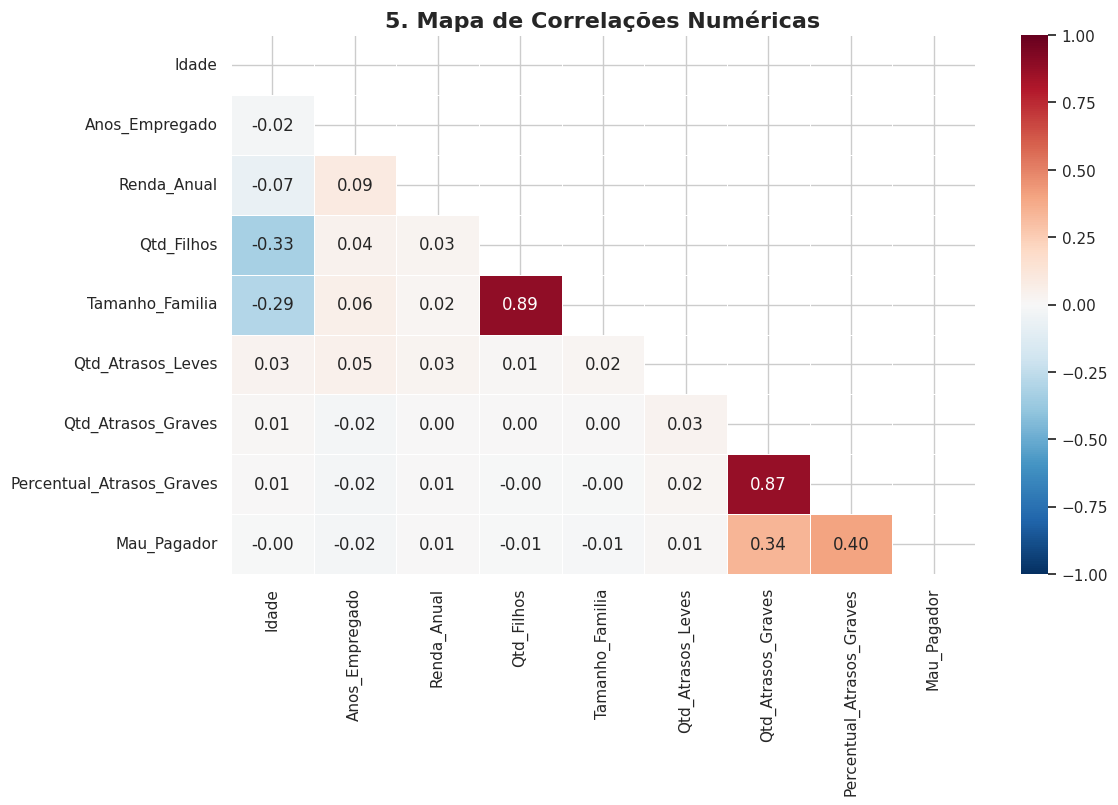

In [19]:
# ==========================================
# CÉLULA 2: ANÁLISE EXPLORATÓRIA VISUAL
# ==========================================

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

fig, axes = plt.subplots(2, 2)
fig.suptitle('Dashboard de Análise de Crédito: Perfil dos Clientes',
             fontsize=20, fontweight='bold', y=1.02)

# --- 1. Distribuição de Bons x Maus Pagadores ---
sns.countplot(data=df, x='Mau_Pagador', palette=['#2ecc71', '#e74c3c'], ax=axes[0,0])
axes[0,0].set_title('1. Distribuição de Bons x Maus Pagadores', fontweight='bold', fontsize=14)
axes[0,0].set_xticklabels(['Bom Pagador', 'Mau Pagador'])
axes[0,0].set_ylabel('Quantidade de Clientes')

# --- 2. Distribuição da Idade ---
sns.histplot(data=df, x='Idade', kde=True, bins=25, color='#3498db', ax=axes[0,1])
axes[0,1].set_title('2. Distribuição Etária dos Requerentes', fontweight='bold', fontsize=14)
axes[0,1].set_xlabel('Idade (Anos)')
axes[0,1].set_ylabel('Frequência')

# --- 3. Renda Anual x Nível de Escolaridade ---
# Outliers já tratados com winsorização na célula anterior, sem necessidade de filtro manual
sns.boxplot(data=df, y='Escolaridade', x='Renda_Anual', palette='viridis', ax=axes[1,0])
axes[1,0].set_title('3. Dispersão de Renda por Nível de Escolaridade', fontweight='bold', fontsize=14)
axes[1,0].set_xlabel('Renda Anual ($)')
axes[1,0].set_ylabel('')

# --- 4. Taxa de Inadimplência por Estado Civil ---
taxa_estado_civil = (
    df.groupby('Estado_Civil')['Mau_Pagador'].mean().sort_values(ascending=False) * 100
)
sns.barplot(x=taxa_estado_civil.values, y=taxa_estado_civil.index, palette='magma', ax=axes[1,1])
axes[1,1].set_title('4. Taxa de Risco (%) por Estado Civil', fontweight='bold', fontsize=14)
axes[1,1].set_xlabel('Taxa de Maus Pagadores (%)')
axes[1,1].set_ylabel('')

plt.tight_layout()
plt.show()

# --- 5. Mapa de Calor (Correlação Numérica) ---
plt.figure(figsize=(12, 7))
cols_numericas = [
    'Idade', 'Anos_Empregado', 'Renda_Anual', 'Qtd_Filhos', 'Tamanho_Familia',
    'Qtd_Atrasos_Leves', 'Qtd_Atrasos_Graves', 'Percentual_Atrasos_Graves', 'Mau_Pagador'
]
correlacao = df[cols_numericas].corr(numeric_only=True)
mask = np.triu(np.ones_like(correlacao, dtype=bool))
sns.heatmap(correlacao, mask=mask, annot=True, cmap='RdBu_r',
            vmin=-1, vmax=1, fmt=".2f", linewidths=.5)
plt.title('5. Mapa de Correlações Numéricas', fontweight='bold', fontsize=16)
plt.show()

In [20]:
# ==========================================
# CÉLULA 3: SEPARAÇÃO E PIPELINE DE PRÉ-PROCESSAMENTO
# ==========================================

X = df.drop(columns=['ID', 'Mau_Pagador'])
y = df['Mau_Pagador']

# Separação treino/teste estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Identificar colunas por tipo
cat_cols    = X_train.select_dtypes(include=['object']).columns.tolist()
robust_cols = ['Renda_Anual', 'Idade', 'Anos_Empregado', 'Qtd_Filhos']
outras_cols = [c for c in X_train.select_dtypes(exclude=['object']).columns
               if c not in robust_cols]

# ──────────────────────────────────────────────────────────────────────────
# USO DE PIPELINE
# ──────────────────────────────────────────────────────────────────────────
# Encapsulamos o pré-processamento num Pipeline do sklearn. Isso garante que:
#   • O TargetEncoder e o RobustScaler são ajustados APENAS nos dados de treino
#     em cada fold da validação cruzada, evitando vazamento de informação.
#   • O RandomizedSearchCV pode otimizar hiperparâmetros do modelo E do
#     pré-processamento de forma integrada e segura.
#   • O modelo final fica num único objeto reutilizável e exportável.

# O Target Encoding foi escolhido porque converte categorias em valores numéricos
# considerando sua relação com a variável alvo Mau_Pagador. Essa técnica é útil
# quando existem muitas categorias, pois evita aumentar muito a quantidade de
# colunas como aconteceria no One-Hot Encoding. Para evitar vazamento de dados,
# o encoder é treinado apenas com os dados de treino.

# O RobustScaler foi escolhido porque essas variáveis podem conter valores extremos,
# especialmente renda anual e tempo de emprego. Ele utiliza mediana e intervalo
# interquartil, sendo menos sensível a outliers do que a padronização tradicional.

preprocessor = ColumnTransformer(
    transformers=[
        ('target_enc', TargetEncoder(),   cat_cols),
        ('robust',     RobustScaler(),    robust_cols),
        ('passthrough', 'passthrough',    outras_cols),
    ],
    remainder='drop'
)

# Pipeline completo: pré-processamento + modelo
pipeline = Pipeline([
    ('prep',  preprocessor),
    ('model', RandomForestClassifier(
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ))
])

print("Pipeline criado com sucesso!")
print(pipeline)

Pipeline criado com sucesso!
Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('target_enc', TargetEncoder(),
                                                  ['Genero', 'Tipo_Renda',
                                                   'Escolaridade',
                                                   'Estado_Civil',
                                                   'Tipo_Moradia',
                                                   'Profissao']),
                                                 ('robust', RobustScaler(),
                                                  ['Renda_Anual', 'Idade',
                                                   'Anos_Empregado',
                                                   'Qtd_Filhos']),
                                                 ('passthrough', 'passthrough',
                                                  ['Tem_Carro', 'Tem_Imovel',
                                                   'Tem_Celular',
            

In [21]:
# ==========================================
# CÉLULA 4: MODELO RANDOM FOREST
# ==========================================

# O Random Forest foi escolhido por ser um algoritmo robusto de classificação,
# baseado na combinação de várias árvores de decisão.
# Ele consegue capturar relações não lineares entre as variáveis,
# reduz o risco de overfitting em comparação com uma única árvore
# e funciona bem em problemas com variáveis numéricas e categóricas codificadas.
# Como o problema envolve classificação de bons e maus pagadores,
# também foi usado class_weight='balanced' para ajudar o modelo a lidar
# com possível desbalanceamento entre as classes.

# Validação cruzada estratificada
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Modelo base
rf_base = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

# Espaço de busca dos hiperparâmetros
param_dist = {
    'model__n_estimators':      [200, 300, 500, 700],
    'model__max_depth':         [None, 5, 10, 15, 20, 30],
    'model__min_samples_split': [2, 5, 10, 20],
    'model__min_samples_leaf':  [1, 2, 4, 8],
    'model__max_features':      ['sqrt', 'log2'],
    'model__bootstrap':         [True],
}

busca_rf = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=30,
    scoring='recall',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

busca_rf.fit(X_train, y_train)

# Pipeline final com os melhores hiperparâmetros
pipeline_final = busca_rf.best_estimator_

print("\nMelhores hiperparâmetros encontrados:")
print(busca_rf.best_params_)
print(f"\nMelhor recall médio na validação cruzada: {busca_rf.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Melhores hiperparâmetros encontrados:
{'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': 'log2', 'model__max_depth': 5, 'model__bootstrap': True}

Melhor recall médio na validação cruzada: 0.4957


Limiar padrão (0.50): usado anteriormente
Limiar otimizado:     0.6490  (maximiza F1-score)
===== MÉTRICAS DO RANDOM FOREST =====
Acurácia:             0.9024
Acurácia balanceada:  0.7342
Precisão:             0.0384
Recall:               0.5636
F1-score:             0.0718
ROC-AUC:              0.8726
Average Precision:    0.3421

===== RELATÓRIO DE CLASSIFICAÇÃO =====
              precision    recall  f1-score   support

 Bom Pagador       1.00      0.90      0.95      8154
 Mau Pagador       0.04      0.56      0.07        55

    accuracy                           0.90      8209
   macro avg       0.52      0.73      0.51      8209
weighted avg       0.99      0.90      0.94      8209



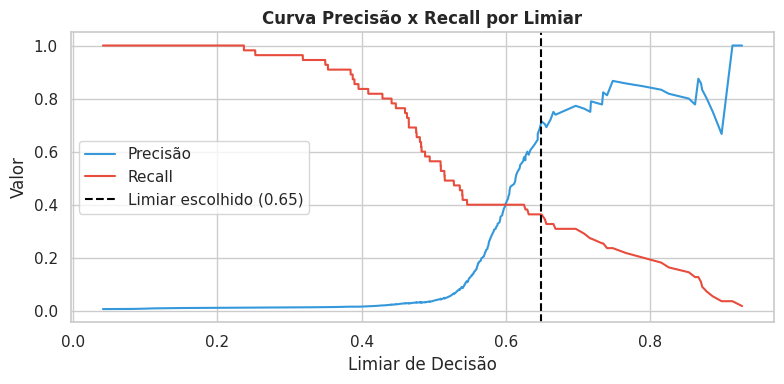

In [23]:
# ==========================================
# CÉLULA 5: AVALIAÇÃO DO MODELO
# ==========================================

# Predição padrão usando limiar 0.5
y_pred = busca_rf.predict(X_test)

# Probabilidade da classe positiva: Mau_Pagador = 1
y_proba = busca_rf.predict_proba(X_test)[:, 1]

precisao_vals, recall_vals, limiares = precision_recall_curve(y_test, y_proba)

# F1 para cada limiar
f1_por_limiar = 2 * (precisao_vals[:-1] * recall_vals[:-1]) / (
    precisao_vals[:-1] + recall_vals[:-1] + 1e-8
)
melhor_idx    = np.argmax(f1_por_limiar)
LIMIAR_FINAL  = limiares[melhor_idx]

print(f"Limiar padrão (0.50): usado anteriormente")
print(f"Limiar otimizado:     {LIMIAR_FINAL:.4f}  (maximiza F1-score)")

print("===== MÉTRICAS DO RANDOM FOREST =====")
print(f"Acurácia:             {accuracy_score(y_test, y_pred):.4f}")
print(f"Acurácia balanceada:  {balanced_accuracy_score(y_test, y_pred):.4f}")
print(f"Precisão:             {precision_score(y_test, y_pred):.4f}")
print(f"Recall:               {recall_score(y_test, y_pred):.4f}")
print(f"F1-score:             {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:              {roc_auc_score(y_test, y_proba):.4f}")
print(f"Average Precision:    {average_precision_score(y_test, y_proba):.4f}")

print("\n===== RELATÓRIO DE CLASSIFICAÇÃO =====")
print(classification_report(
    y_test,
    y_pred,
    target_names=['Bom Pagador', 'Mau Pagador']
))

# --- Curva Precision-Recall: mostra o tradeoff para cada limiar possível ---
plt.figure(figsize=(8, 4))
plt.plot(limiares, precisao_vals[:-1], label='Precisão', color='#3498db')
plt.plot(limiares, recall_vals[:-1],   label='Recall',    color='#e74c3c')
plt.axvline(LIMIAR_FINAL, color='black', linestyle='--', label=f'Limiar escolhido ({LIMIAR_FINAL:.2f})')
plt.xlabel('Limiar de Decisão')
plt.ylabel('Valor')
plt.title('Curva Precisão x Recall por Limiar', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

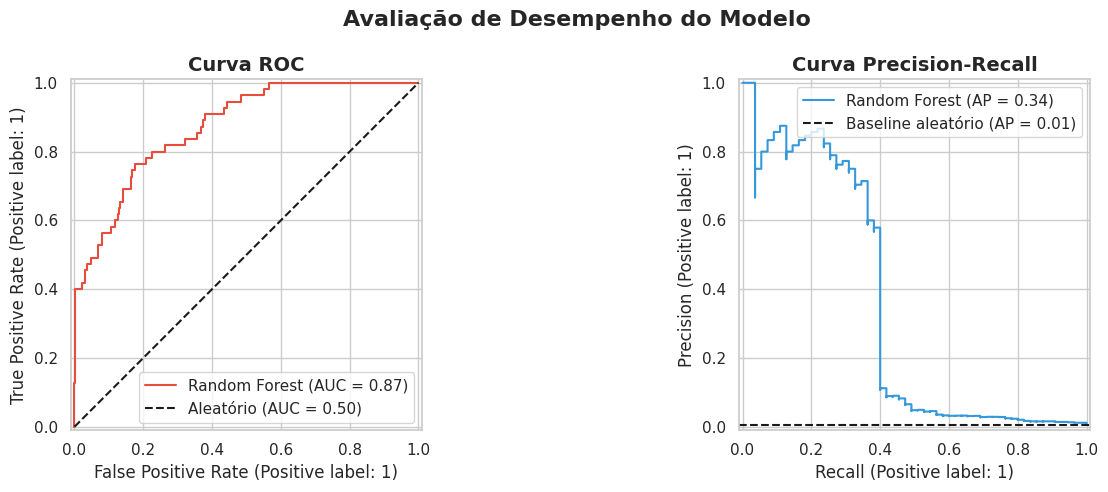

In [24]:
# ==========================================
# CÉLULA 6: CURVAS ROC E PRECISION-RECALL
# ==========================================

# As curvas ROC e Precision-Recall são complementares:
#   • ROC-AUC: mede a capacidade geral de separação entre classes.
#     Útil quando as classes são razoavelmente balanceadas.
#   • Precision-Recall AUC (Average Precision): mais informativa em
#     problemas desbalanceados, como detecção de maus pagadores, pois
#     foca no desempenho sobre a classe minoritária (positiva).
# Um modelo aleatório teria ROC-AUC ≈ 0.50 e PR-AUC ≈ taxa de maus pagadores.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(
    y_test, y_proba, ax=ax1, color='#e74c3c', name='Random Forest'
)
ax1.plot([0, 1], [0, 1], 'k--', label='Aleatório (AUC = 0.50)')
ax1.set_title('Curva ROC', fontweight='bold', fontsize=14)
ax1.legend()

PrecisionRecallDisplay.from_predictions(
    y_test, y_proba, ax=ax2, color='#3498db', name='Random Forest'
)
ax2.axhline(
    y=y_test.mean(), color='k', linestyle='--',
    label=f'Baseline aleatório (AP = {y_test.mean():.2f})'
)
ax2.set_title('Curva Precision-Recall', fontweight='bold', fontsize=14)
ax2.legend()

plt.suptitle('Avaliação de Desempenho do Modelo', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

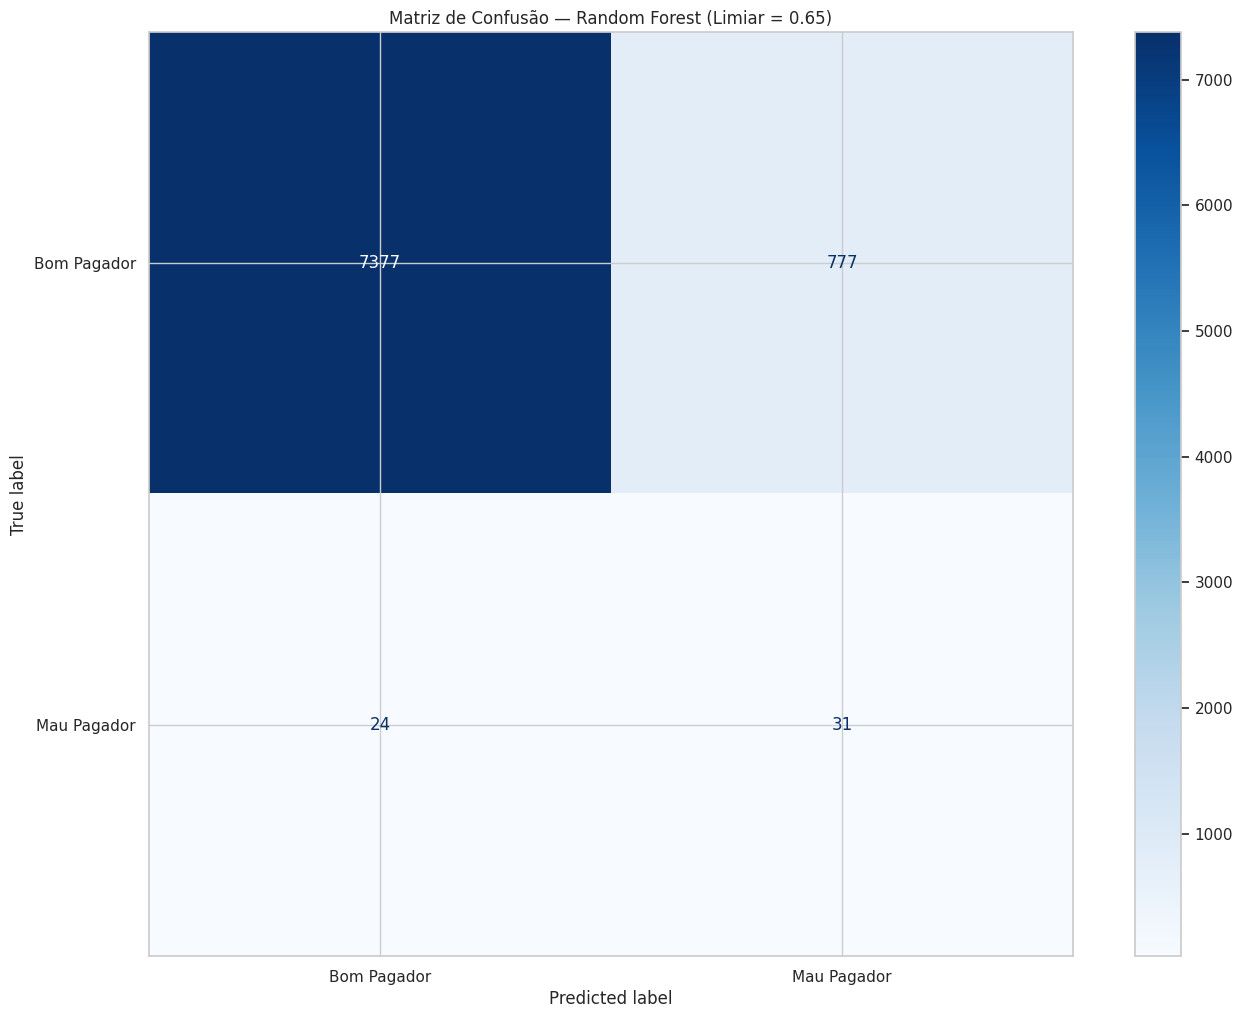

Verdadeiros Negativos (acertou bom pagador):   7377
Falsos Positivos (negou crédito indevidamente): 777
Falsos Negativos (liberou crédito p/ inadimp.): 24  ← custo mais alto
Verdadeiros Positivos (pegou mau pagador):      31


In [28]:
# ==========================================
# CÉLULA 7: MATRIZ DE CONFUSÃO
# ==========================================

# A matriz de confusão com o LIMIAR AJUSTADO mostra o impacto real da
# decisão de negócio. Compare com o limiar padrão 0.5 para ver a diferença.

matriz = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=['Bom Pagador', 'Mau Pagador']
)

disp.plot(cmap='Blues')
plt.title(f"Matriz de Confusão — Random Forest (Limiar = {LIMIAR_FINAL:.2f})")
plt.show()

vn, fp, fn, vp = matriz.ravel()
print(f"Verdadeiros Negativos (acertou bom pagador):   {vn}")
print(f"Falsos Positivos (negou crédito indevidamente): {fp}")
print(f"Falsos Negativos (liberou crédito p/ inadimp.): {fn}  ← custo mais alto")
print(f"Verdadeiros Positivos (pegou mau pagador):      {vp}")